In [1]:
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import List, Dict, Optional
import json, uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.random.seed(7)

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
prevention_dir = data_dir / 'prevention'
audit_dir = data_dir / 'audit'
prevention_dir.mkdir(parents=True, exist_ok=True)
audit_dir.mkdir(parents=True, exist_ok=True)

AUDIT_LOG_PATH = audit_dir / 'audit_log.jsonl'
OPERATOR = 'prasenjit.roychoudhury'

def audit_event(event_type, incident_id, payload):
    record = {
        'audit_id': f'aud-{uuid.uuid4().hex[:12]}',
        'timestamp_utc': datetime.now(timezone.utc).isoformat(),
        'event_type': event_type,
        'incident_id': incident_id,
        'operator': OPERATOR,
        'payload': payload,
    }
    with open(AUDIT_LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(json.dumps(record, default=str) + '\n')
    return record

print('UC-5 module ready. Prevention dir:', prevention_dir)

UC-5 module ready. Prevention dir: /workspace/shared/agents026/data/prevention


In [2]:
# Scenario: checkout-api latency creeping up (connection-pool leak pattern)
# 90 minutes of live telemetry at 1-min resolution
SERVICE = 'checkout-api'
LATENCY_THRESHOLD = 400.0          # same SLO threshold as Phase 3 detection
N_MIN = 90
LIVE_START = datetime(2026, 6, 11, 9, 0, 0)

idx = pd.date_range(LIVE_START, periods=N_MIN, freq='1min')

base = 150.0
noise = np.random.normal(0, 8, N_MIN)
# Healthy until minute 30, then a leak begins: ~4.5 ms/min upward drift
trend = np.concatenate([np.zeros(30), 4.5 * np.arange(N_MIN - 30)])

live_df = pd.DataFrame({
    'timestamp': idx,
    'service': SERVICE,
    'latency_p95_ms': (base + trend + noise).clip(50, None),
})

print(f'Live stream: {N_MIN} min for {SERVICE}')
print(f'Latency at min 0: {live_df.latency_p95_ms.iloc[0]:.0f}ms | at min 89: {live_df.latency_p95_ms.iloc[-1]:.0f}ms | threshold: {LATENCY_THRESHOLD:.0f}ms')
breach_idx = (live_df.latency_p95_ms > LATENCY_THRESHOLD).idxmax()
print(f'Actual threshold breach occurs at minute {breach_idx} ({live_df.timestamp.iloc[breach_idx]})')

Live stream: 90 min for checkout-api
Latency at min 0: 164ms | at min 89: 421ms | threshold: 400ms
Actual threshold breach occurs at minute 87 (2026-06-11 10:27:00)


In [3]:
def forecast_breach(series: pd.Series, threshold: float, lookback: int = 15,
                    horizon: int = 30, min_r2: float = 0.6) -> Dict:
    """
    Fit a linear trend on the last `lookback` points.
    Returns predicted minutes-to-breach if a breach is forecast within `horizon`
    and the trend fit is confident (R^2 >= min_r2). Otherwise status=ok.
    """
    if len(series) < lookback:
        return {'status': 'insufficient_data'}

    y = series.tail(lookback).to_numpy()
    x = np.arange(lookback)
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    current = float(y[-1])
    if slope <= 0.1 or current >= threshold:
        return {'status': 'ok' if current < threshold else 'already_breached',
                'current': current, 'slope_per_min': float(slope), 'r2': float(r2)}

    minutes_to_breach = (threshold - current) / slope
    if minutes_to_breach <= horizon and r2 >= min_r2:
        return {'status': 'warning', 'current': current,
                'slope_per_min': float(slope), 'r2': float(r2),
                'predicted_minutes_to_breach': float(minutes_to_breach)}
    return {'status': 'ok', 'current': current, 'slope_per_min': float(slope), 'r2': float(r2)}

print('Forecaster ready (linear trend, lookback=15min, horizon=30min)')

Forecaster ready (linear trend, lookback=15min, horizon=30min)


In [4]:
warning = None
warning_minute = None
timeline = []

for t in range(20, N_MIN):
    window = live_df.latency_p95_ms.iloc[:t+1]
    f = forecast_breach(window, LATENCY_THRESHOLD)
    timeline.append({'minute': t, **{k: v for k, v in f.items() if k != 'status'}, 'status': f['status']})
    if f['status'] == 'warning' and warning is None:
        warning = f
        warning_minute = t
        break   # first warning is the actionable moment

if warning:
    lead_time = breach_idx - warning_minute
    display(Markdown(
        f"## ⚠️ PRE-INCIDENT WARNING raised at minute {warning_minute} "
        f"({live_df.timestamp.iloc[warning_minute].strftime('%H:%M')})\n"
        f"- **Current latency:** {warning['current']:.0f}ms (threshold {LATENCY_THRESHOLD:.0f}ms — still healthy!)\n"
        f"- **Trend:** +{warning['slope_per_min']:.1f} ms/min (R²={warning['r2']:.2f})\n"
        f"- **Predicted breach in:** {warning['predicted_minutes_to_breach']:.0f} minutes\n"
        f"- **Actual breach would occur at minute {breach_idx}** → the agent has **{lead_time} minutes of lead time** to prevent the incident"
    ))
    audit_event('pre_incident_warning', 'prev-001', {
        'service': SERVICE, 'metric': 'latency_p95_ms',
        'current_value': warning['current'], 'threshold': LATENCY_THRESHOLD,
        'slope_per_min': warning['slope_per_min'], 'r2': warning['r2'],
        'predicted_minutes_to_breach': warning['predicted_minutes_to_breach'],
        'warning_time': str(live_df.timestamp.iloc[warning_minute]),
    })
else:
    print('No warning raised — tell Claude (trend parameters may need tuning)')

## ⚠️ PRE-INCIDENT WARNING raised at minute 53 (09:53)
- **Current latency:** 256ms (threshold 400ms — still healthy!)
- **Trend:** +5.0 ms/min (R²=0.87)
- **Predicted breach in:** 29 minutes
- **Actual breach would occur at minute 87** → the agent has **34 minutes of lead time** to prevent the incident

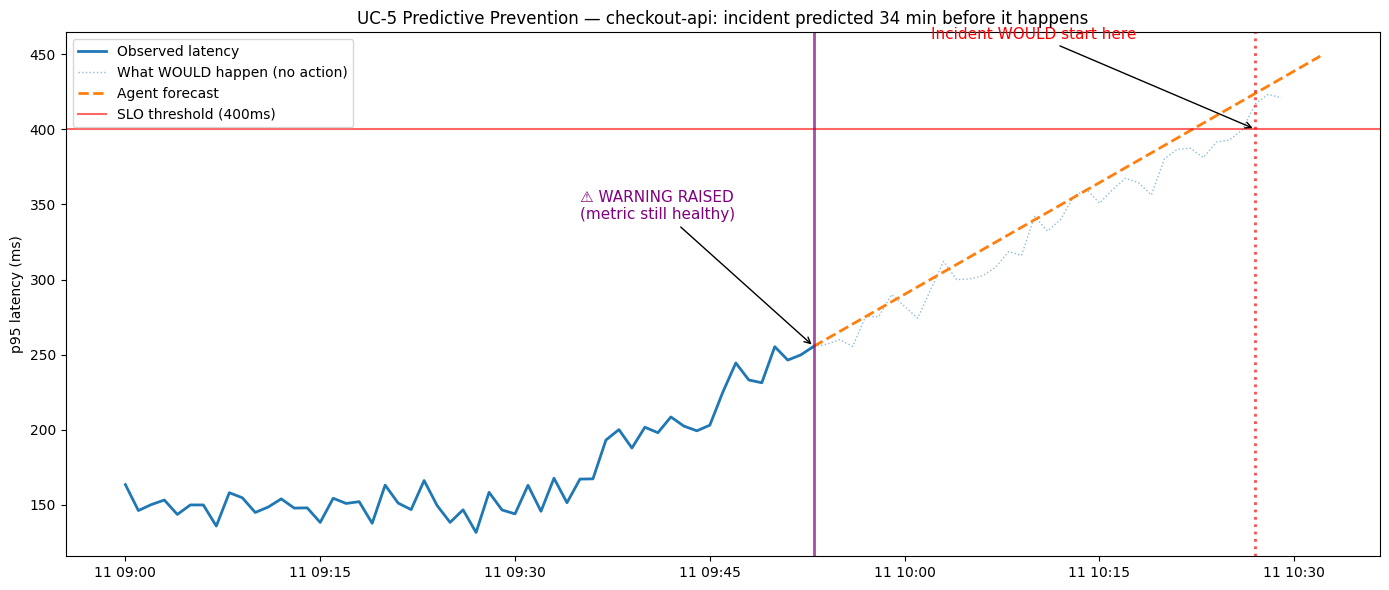

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Actual telemetry up to warning point (what the agent has seen)
seen = live_df.iloc[:warning_minute+1]
future = live_df.iloc[warning_minute:]
ax.plot(seen.timestamp, seen.latency_p95_ms, color='tab:blue', lw=2, label='Observed latency')
ax.plot(future.timestamp, future.latency_p95_ms, color='tab:blue', lw=1, ls=':', alpha=0.5, label='What WOULD happen (no action)')

# Forecast line from warning point
mins = np.arange(0, 40)
forecast_line = warning['current'] + warning['slope_per_min'] * mins
ax.plot([live_df.timestamp.iloc[warning_minute] + timedelta(minutes=int(m)) for m in mins],
        forecast_line, color='tab:orange', ls='--', lw=2, label='Agent forecast')

ax.axhline(LATENCY_THRESHOLD, color='red', ls='-', alpha=0.6, label=f'SLO threshold ({LATENCY_THRESHOLD:.0f}ms)')
ax.axvline(live_df.timestamp.iloc[warning_minute], color='purple', ls='-', lw=2, alpha=0.7)
ax.annotate('⚠️ WARNING RAISED\n(metric still healthy)',
            xy=(live_df.timestamp.iloc[warning_minute], warning['current']),
            xytext=(live_df.timestamp.iloc[warning_minute - 18], LATENCY_THRESHOLD - 60),
            arrowprops=dict(arrowstyle='->'), fontsize=11, color='purple')
ax.axvline(live_df.timestamp.iloc[breach_idx], color='red', ls=':', lw=2, alpha=0.7)
ax.annotate('Incident WOULD start here', xy=(live_df.timestamp.iloc[breach_idx], LATENCY_THRESHOLD),
            xytext=(live_df.timestamp.iloc[breach_idx - 25], LATENCY_THRESHOLD + 60),
            arrowprops=dict(arrowstyle='->'), fontsize=11, color='red')

ax.set_title(f'UC-5 Predictive Prevention — {SERVICE}: incident predicted {breach_idx - warning_minute} min before it happens')
ax.set_ylabel('p95 latency (ms)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

✅ Preventive action executed: scale_service on checkout-api (+2 replicas)
   Policy: auto-approved (low-risk action type)


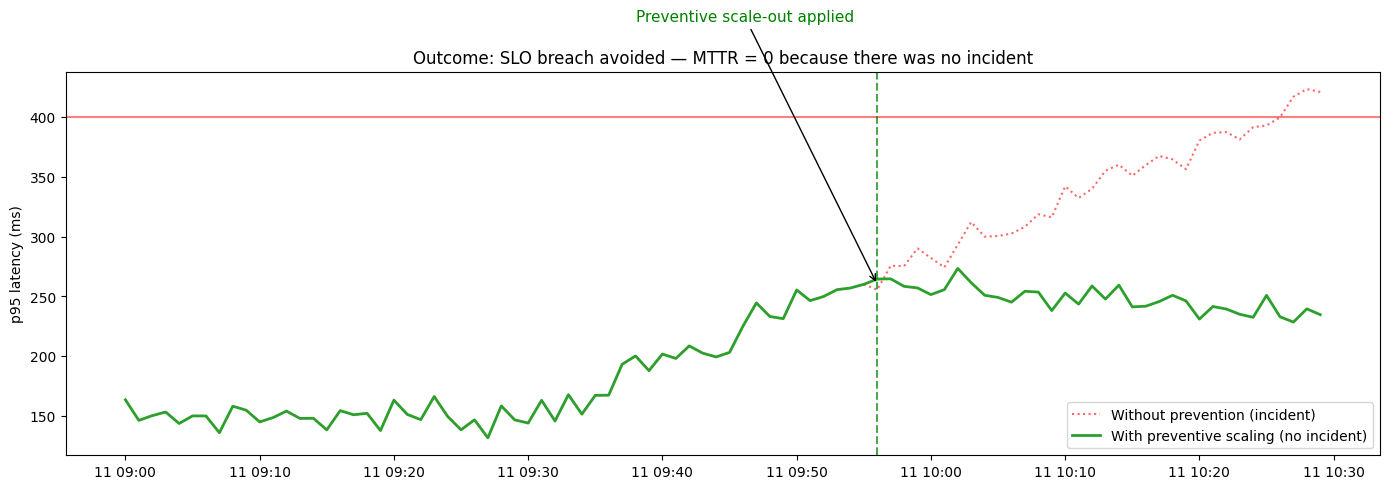


Peak latency with prevention: 273ms (threshold 400ms) — breach avoided ✅


In [6]:
POLICY_AUTO = ['restart_service', 'scale_service', 'clear_cache']

preventive_action = {
    'action_id': f'act-{uuid.uuid4().hex[:8]}',
    'action_type': 'scale_service',
    'target': SERVICE,
    'description': f'Preventive scale-out of {SERVICE} (+2 replicas) to absorb the degrading latency trend before SLO breach.',
    'parameters': {'replicas_delta': 2},
    'requires_approval': 'scale_service' not in POLICY_AUTO,
    'status': 'pending',
    'trigger': 'pre_incident_warning prev-001',
}

# Execute (auto-approved by policy)
preventive_action['status'] = 'executed'
audit_event('preventive_action_executed', 'prev-001', preventive_action)
print(f"✅ Preventive action executed: {preventive_action['action_type']} on {SERVICE} (+2 replicas)")
print('   Policy: auto-approved (low-risk action type)')

# Simulate the counterfactual: post-action, the trend flattens
prevented = live_df.copy()
post = slice(warning_minute + 3, None)   # action takes effect ~3 min after warning
flat = prevented.latency_p95_ms.iloc[warning_minute + 2]
n_post = len(prevented.latency_p95_ms.iloc[post])
prevented.loc[prevented.index[post], 'latency_p95_ms'] = flat + np.random.normal(0, 8, n_post) - 0.8 * np.arange(n_post)
prevented['latency_p95_ms'] = prevented['latency_p95_ms'].clip(50, None)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(live_df.timestamp, live_df.latency_p95_ms, ls=':', color='red', alpha=0.6, label='Without prevention (incident)')
ax.plot(prevented.timestamp, prevented.latency_p95_ms, color='tab:green', lw=2, label='With preventive scaling (no incident)')
ax.axhline(LATENCY_THRESHOLD, color='red', alpha=0.5)
ax.axvline(live_df.timestamp.iloc[warning_minute + 3], color='green', ls='--', alpha=0.7)
ax.annotate('Preventive scale-out applied', xy=(live_df.timestamp.iloc[warning_minute + 3], flat),
            xytext=(live_df.timestamp.iloc[warning_minute - 15], LATENCY_THRESHOLD + 80),
            arrowprops=dict(arrowstyle='->'), color='green', fontsize=11)
ax.set_title('Outcome: SLO breach avoided — MTTR = 0 because there was no incident')
ax.set_ylabel('p95 latency (ms)')
ax.legend()
plt.tight_layout()
plt.show()

max_prevented = prevented.latency_p95_ms.iloc[warning_minute:].max()
print(f'\nPeak latency with prevention: {max_prevented:.0f}ms (threshold {LATENCY_THRESHOLD:.0f}ms) — breach avoided ✅')

In [7]:
prevention_bundle = {
    'prevention_id': 'prev-001',
    'service': SERVICE,
    'metric': 'latency_p95_ms',
    'threshold': LATENCY_THRESHOLD,
    'warning': {**warning, 'warning_minute': int(warning_minute),
                'warning_time': str(live_df.timestamp.iloc[warning_minute])},
    'lead_time_minutes': int(breach_idx - warning_minute),
    'preventive_action': preventive_action,
    'outcome': 'breach_avoided',
    'peak_latency_with_prevention_ms': float(max_prevented),
}

with open(prevention_dir / 'prev-001_prevention.json', 'w', encoding='utf-8') as f:
    json.dump(prevention_bundle, f, default=str, indent=2)

live_df.to_csv(prevention_dir / 'live_stream_no_action.csv', index=False)
prevented.to_csv(prevention_dir / 'live_stream_prevented.csv', index=False)

display(Markdown(f'''
### UC-5 Summary
| | |
|---|---|
| Warning raised | minute {warning_minute} (latency {warning['current']:.0f}ms — below threshold) |
| Predicted breach | {warning['predicted_minutes_to_breach']:.0f} min ahead |
| Actual breach (counterfactual) | minute {breach_idx} |
| **Lead time** | **{breach_idx - warning_minute} minutes** |
| Preventive action | scale_service +2 (auto-approved by policy) |
| Outcome | **Incident never happened — MTTR = 0** |
| Audit | warning + action logged to compliance trail |
'''))
print('Saved:', prevention_dir / 'prev-001_prevention.json')


### UC-5 Summary
| | |
|---|---|
| Warning raised | minute 53 (latency 256ms — below threshold) |
| Predicted breach | 29 min ahead |
| Actual breach (counterfactual) | minute 87 |
| **Lead time** | **34 minutes** |
| Preventive action | scale_service +2 (auto-approved by policy) |
| Outcome | **Incident never happened — MTTR = 0** |
| Audit | warning + action logged to compliance trail |


Saved: /workspace/shared/agents026/data/prevention/prev-001_prevention.json
